In [8]:
##### Creates scatterplot of pixel share of actual vs predicted sub-national intensities

import os
import pandas as pd
import geopandas as gpd
import rioxarray as rio
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from glob import glob
import rasterio
from rasterio.warp import reproject, Resampling
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
from pyproj import Transformer
import rasterio
from scipy import stats

In [9]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# import reference data 
ref_data = pd.read_csv(f"{cd}/Data/Clean/Intensities/intensities_for_eval.csv")

# import model predictions
capital_rf = pd.read_parquet(f'{cd}/Results/RF_models_final/capital_rf_spatial_CV/predictions.parquet')
labor_rf = pd.read_parquet(f'{cd}/Results/RF_models_final/labor_rf_spatial_CV/predictions.parquet')

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/plot_actual_predicted"

In [10]:
##### PREP DATA

# Add original intensity data (sub-national and country) for evaluation
capital_rf = capital_rf.merge(ref_data, on=['PROJ_ID', 'country_ID'], how='left')
labor_rf = labor_rf.merge(ref_data, on=['PROJ_ID', 'country_ID'], how='left')

# Estimate actual predicted intensity (not relative)
capital_rf['predicted_log_capital_intensity_USD_per_million_tonne'] = capital_rf['prediction'] + capital_rf['log_country_capital_intensity_USD_per_million_tonne']
capital_rf['predicted_capital_intensity_USD_per_million_tonne'] = np.expm1(capital_rf['predicted_log_capital_intensity_USD_per_million_tonne'])

labor_rf['predicted_log_labor_intensity_jobs_per_million_tonne'] = labor_rf['prediction'] + labor_rf['log_country_labor_intensity_jobs_per_million_tonne']
labor_rf['predicted_labor_intensity_jobs_per_million_tonne'] = np.expm1(labor_rf['predicted_log_labor_intensity_jobs_per_million_tonne'])

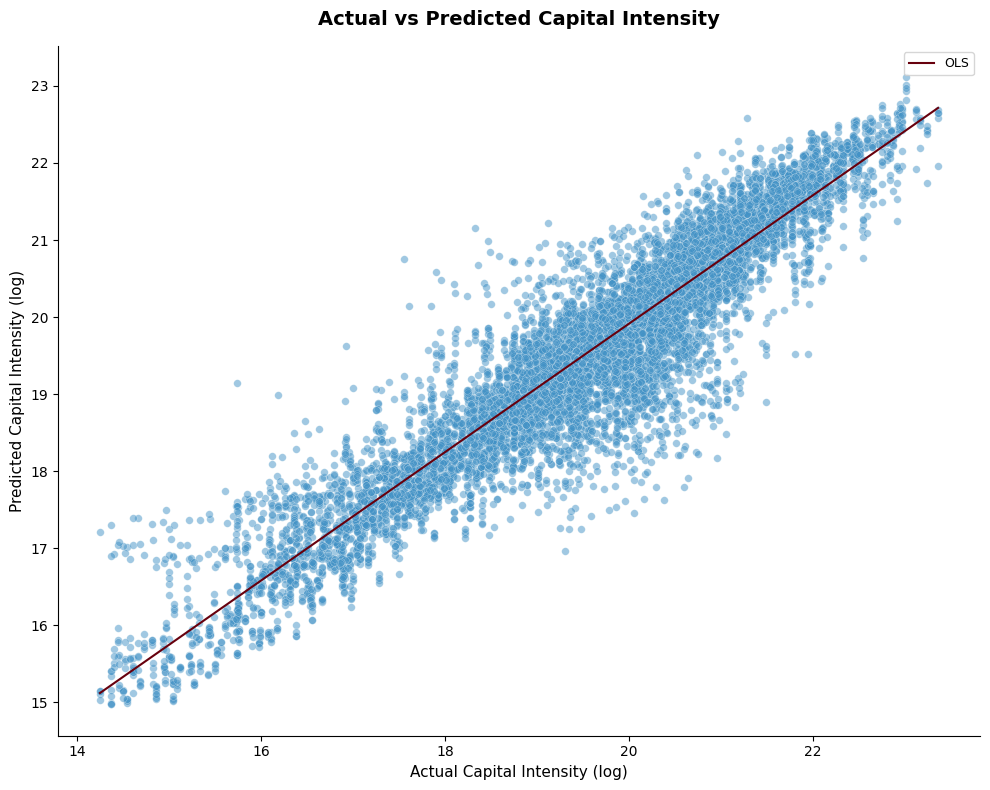

In [11]:
##### Scatterplot of actual vs predicted capital intensity 

fig, ax = plt.subplots(figsize=(10, 8))

# Scatter
ax.scatter(
    capital_rf['log_region_capital_intensity_USD_per_million_tonne'],
    capital_rf['predicted_log_capital_intensity_USD_per_million_tonne'],
    color='#4292c6',
    alpha=0.5,
    edgecolors='white',
    linewidths=0.3,
    s=30,
    zorder=2
)

# OLS trend line
mask = capital_rf[['log_region_capital_intensity_USD_per_million_tonne', 'predicted_log_capital_intensity_USD_per_million_tonne']].notna().all(axis=1)
x = capital_rf.loc[mask, 'log_region_capital_intensity_USD_per_million_tonne']
y = capital_rf.loc[mask, 'predicted_log_capital_intensity_USD_per_million_tonne']

slope, intercept, r, p, _ = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, intercept + slope * x_line, color='#67000d', linewidth=1.5, zorder=3, label=f'OLS')

# Aesthetics
ax.set_xlabel("Actual Capital Intensity (log)", fontsize=11)
ax.set_ylabel("Predicted Capital Intensity (log)", fontsize=11)
ax.set_title("Actual vs Predicted Capital Intensity", fontsize=14, weight='bold', pad=15)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f"{fd}/scatterplot_capital_log.png", dpi=300, bbox_inches='tight')
plt.show()

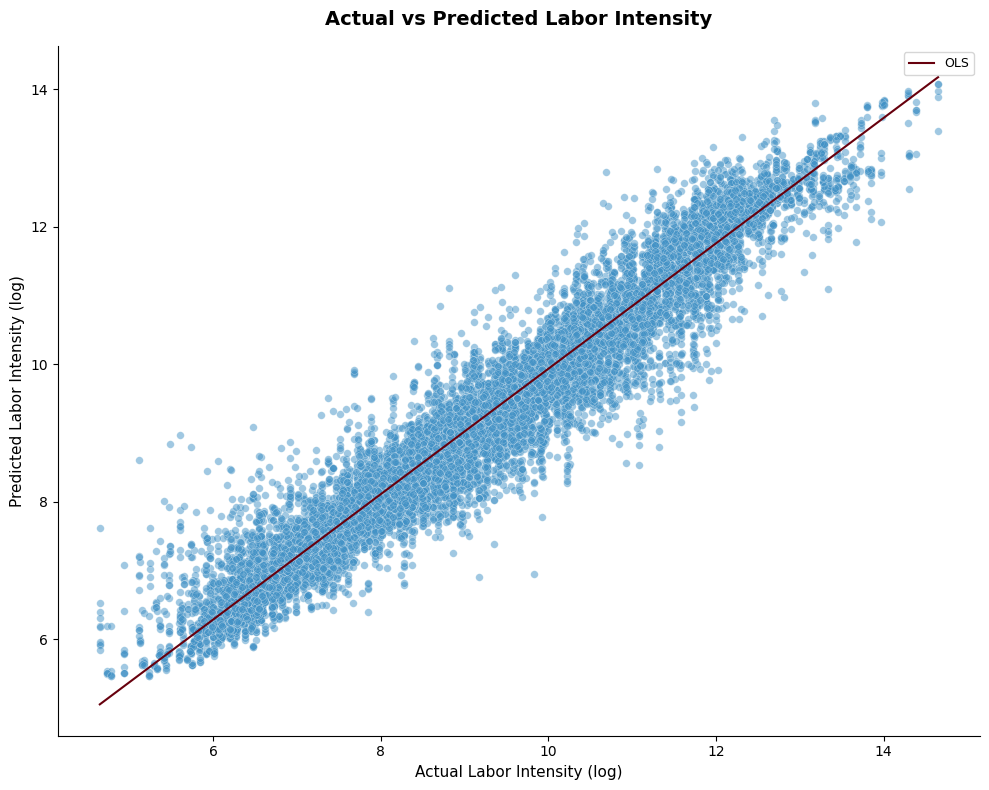

In [12]:
##### Scatterplot of actual vs predicted labor intensity 

fig, ax = plt.subplots(figsize=(10, 8))

# Scatter
ax.scatter(
    labor_rf['log_region_labor_intensity_jobs_per_million_tonne'],
    labor_rf['predicted_log_labor_intensity_jobs_per_million_tonne'],
    color='#4292c6',
    alpha=0.5,
    edgecolors='white',
    linewidths=0.3,
    s=30,
    zorder=2
)

# OLS trend line
mask = labor_rf[['log_region_labor_intensity_jobs_per_million_tonne', 'predicted_log_labor_intensity_jobs_per_million_tonne']].notna().all(axis=1)
x = labor_rf.loc[mask, 'log_region_labor_intensity_jobs_per_million_tonne']
y = labor_rf.loc[mask, 'predicted_log_labor_intensity_jobs_per_million_tonne']

slope, intercept, r, p, _ = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, intercept + slope * x_line, color='#67000d', linewidth=1.5, zorder=3, label=f'OLS')

# Aesthetics
ax.set_xlabel("Actual Labor Intensity (log)", fontsize=11)
ax.set_ylabel("Predicted Labor Intensity (log)", fontsize=11)
ax.set_title("Actual vs Predicted Labor Intensity", fontsize=14, weight='bold', pad=15)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f"{fd}/scatterplot_labor_log.png", dpi=300, bbox_inches='tight')
plt.show()

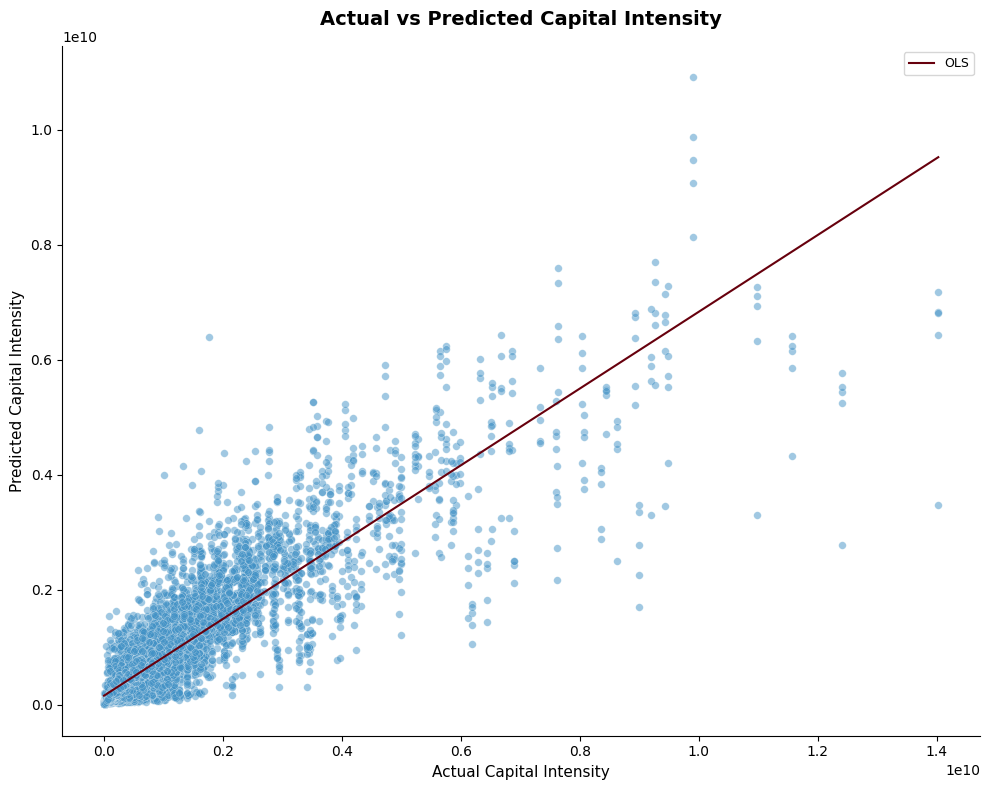

In [13]:
##### Scatterplot of actual vs predicted capital intensity 

fig, ax = plt.subplots(figsize=(10, 8))

# Scatter
ax.scatter(
    capital_rf['region_capital_intensity_USD_per_million_tonne'],
    capital_rf['predicted_capital_intensity_USD_per_million_tonne'],
    color='#4292c6',
    alpha=0.5,
    edgecolors='white',
    linewidths=0.3,
    s=30,
    zorder=2
)

# OLS trend line
mask = capital_rf[['region_capital_intensity_USD_per_million_tonne', 'predicted_capital_intensity_USD_per_million_tonne']].notna().all(axis=1)
x = capital_rf.loc[mask, 'region_capital_intensity_USD_per_million_tonne']
y = capital_rf.loc[mask, 'predicted_capital_intensity_USD_per_million_tonne']

slope, intercept, r, p, _ = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, intercept + slope * x_line, color='#67000d', linewidth=1.5, zorder=3, label=f'OLS')

# Aesthetics
ax.set_xlabel("Actual Capital Intensity", fontsize=11)
ax.set_ylabel("Predicted Capital Intensity", fontsize=11)
ax.set_title("Actual vs Predicted Capital Intensity", fontsize=14, weight='bold', pad=15)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f"{fd}/scatterplot_capital.png", dpi=300, bbox_inches='tight')
plt.show()

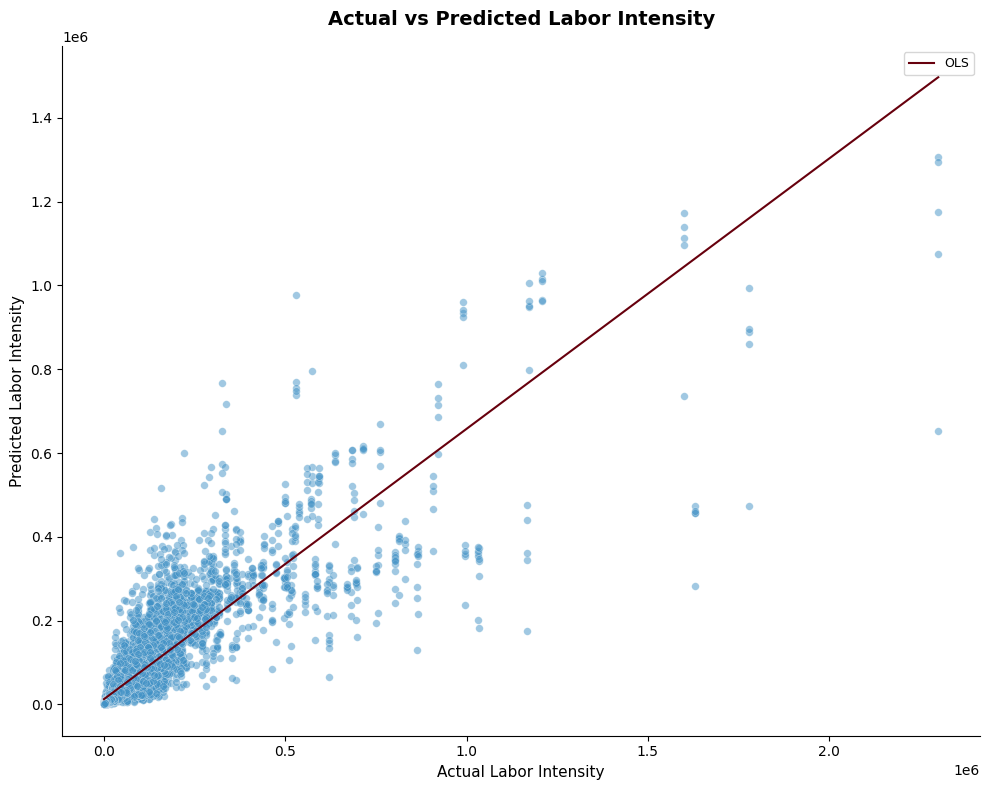

In [14]:
##### Scatterplot of actual vs predicted labor intensity 

fig, ax = plt.subplots(figsize=(10, 8))

# Scatter
ax.scatter(
    labor_rf['region_labor_intensity_jobs_per_million_tonne'],
    labor_rf['predicted_labor_intensity_jobs_per_million_tonne'],
    color='#4292c6',
    alpha=0.5,
    edgecolors='white',
    linewidths=0.3,
    s=30,
    zorder=2
)

# OLS trend line
mask = labor_rf[['region_labor_intensity_jobs_per_million_tonne', 'predicted_labor_intensity_jobs_per_million_tonne']].notna().all(axis=1)
x = labor_rf.loc[mask, 'region_labor_intensity_jobs_per_million_tonne']
y = labor_rf.loc[mask, 'predicted_labor_intensity_jobs_per_million_tonne']

slope, intercept, r, p, _ = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, intercept + slope * x_line, color='#67000d', linewidth=1.5, zorder=3, label=f'OLS')

# Aesthetics
ax.set_xlabel("Actual Labor Intensity", fontsize=11)
ax.set_ylabel("Predicted Labor Intensity", fontsize=11)
ax.set_title("Actual vs Predicted Labor Intensity", fontsize=14, weight='bold', pad=15)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f"{fd}/scatterplot_labor.png", dpi=300, bbox_inches='tight')
plt.show()